<a href="https://colab.research.google.com/github/barepgaming-sys/Ann-dry-bean-kelompok-3/blob/main/Tugas_Besar_ANN_keras_NabilaRahayu(2303030015)_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TUGAS BESAR KECERDASA BUATAN

## Implementasi Artificial Neural Network (ANN) Menggunakan TensorFlow Keras

**Nama Kelompok:** (Nabila Rahayu & Barep Purwo Agusto)

**Mata Kuliah:** Kecerdasan Buatan

**Dataset:** Dry Bean Dataset

**Framework:** TensorFlow Keras

**Optimizer:** SGD

**Learning Rate:** 0.1

**Epoch:** 50

**Batch Size:** 16

**Metode Inisialisasi Bobot yang Dibandingkan**

- Zero Initialization
- Xavier Initialization
- He Initialization

In [ ]:
import pandas as pd

In [ ]:
import pandas as pd

df = pd.read_excel("Dry_Bean_Dataset.xlsx")

In [ ]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [ ]:
df.shape

(13611, 17)

In [ ]:
df.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [ ]:
df["Class"].value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


In [ ]:
import pandas as pd

df = pd.read_excel("Dry_Bean_Dataset.xlsx")

In [ ]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
X = df.iloc[:, :-1]

y = df.iloc[:, -1]

In [ ]:
print(X.head())

    Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395    610.291       208.178117       173.888747      1.197191   
1  28734    638.018       200.524796       182.734419      1.097356   
2  29380    624.110       212.826130       175.931143      1.209713   
3  30008    645.884       210.557999       182.516516      1.153638   
4  30140    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812       28715     190.141097  0.763923  0.988856   0.958027   
1      0.411785       29172     191.272750  0.783968  0.984986   0.887034   
2      0.562727       29690     193.410904  0.778113  0.989559   0.947849   
3      0.498616       30724     195.467062  0.782681  0.976696   0.903936   
4      0.333680       30417     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  
0     0.913358      0.007332      0.0

In [ ]:
print(y.head())

0    SEKER
1    SEKER
2    SEKER
3    SEKER
4    SEKER
Name: Class, dtype: object


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [ ]:
print(y[:10])

[5 5 5 5 5 5 5 5 5 5]


In [ ]:
from tensorflow.keras.utils import to_categorical

In [ ]:
y = to_categorical(y)

In [ ]:
print(y[0])

[0. 0. 0. 0. 0. 1. 0.]


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(10888, 16)
(2723, 16)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
model = Sequential()

In [ ]:
model.add(Dense(
    units=32,
    activation='relu',
    input_shape=(16,)
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.add(Dense(
    units=7,
    activation='softmax'
))

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775 (3.03 KB)

 Trainable params: 775 (3.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def build_model(initializer):

    model = Sequential()

    model.add(Dense(
        units=32,
        activation='relu',
        input_shape=(16,),
        kernel_initializer=initializer
    ))

    model.add(Dense(
        units=7,
        activation='softmax',
        kernel_initializer=initializer
    ))

    return model

In [ ]:
model = build_model("zeros")

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 775 (3.03 KB)

 Trainable params: 775 (3.03 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import SGD

In [ ]:
optimizer = SGD(
    learning_rate=0.1
)

In [ ]:
from tensorflow.keras.optimizers import SGD

In [ ]:
optimizer = SGD(
    learning_rate=0.1
)

In [ ]:
model.compile(
    optimizer=optimizer,
    loss='mean_squared_error',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2633 - loss: 0.1211 - val_accuracy: 0.2464 - val_loss: 0.1202
Epoch 2/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.2641 - loss: 0.1193 - val_accuracy: 0.2464 - val_loss: 0.1194
Epoch 3/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2641 - loss: 0.1187 - val_accuracy: 0.2464 - val_loss: 0.1191
Epoch 4/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.2641 - loss: 0.1184 - val_accuracy: 0.2464 - val_loss: 0.1189
Epoch 5/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2641 - loss: 0.1183 - val_accuracy: 0.2464 - val_loss: 0.1189
Epoch 6/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2641 - loss: 0.1182 - val_accuracy: 0.2464 - val_loss: 0.1188
Epoch 7/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2641 - loss: 0.1182 - val_accuracy: 0.2464 - val_loss: 0.1188
Epoch 8/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2641 - loss: 0.1182 - val_accuracy: 0.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt

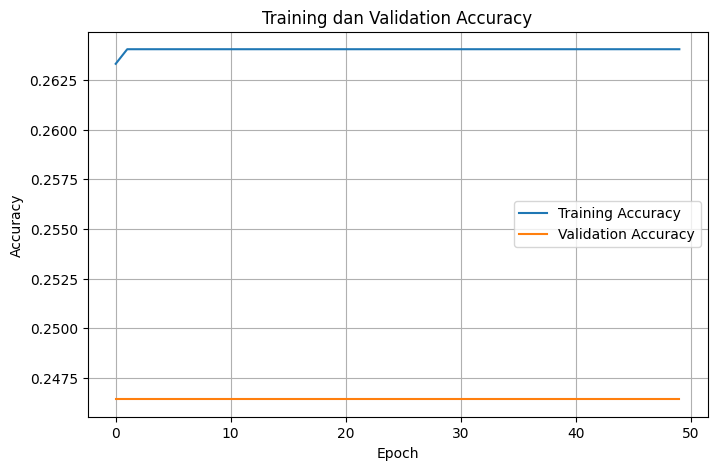

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training dan Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend()

plt.grid(True)

plt.show()

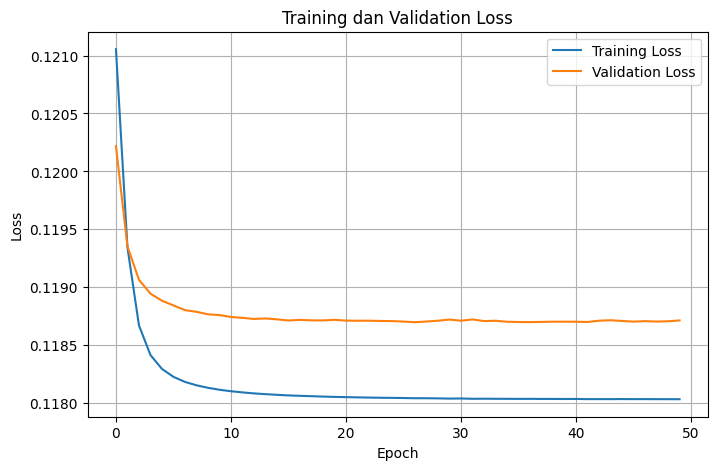

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training dan Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.show()

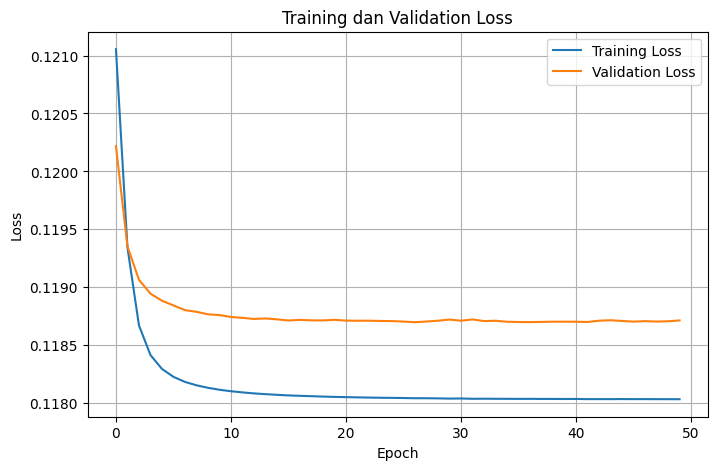

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training dan Validation Loss')

plt.xlabel('Epoch')

plt.ylabel('Loss')

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
model = build_model("glorot_uniform")

In [ ]:
from tensorflow.keras.optimizers import SGD

optimizer = SGD(
    learning_rate=0.1
)

model.compile(
    optimizer=optimizer,
    loss='mean_squared_error',
    metrics=['accuracy']
)

In [ ]:
history_xavier = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5796 - loss: 0.0759 - val_accuracy: 0.7429 - val_loss: 0.0542
Epoch 2/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8320 - loss: 0.0431 - val_accuracy: 0.8832 - val_loss: 0.0342
Epoch 3/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9012 - loss: 0.0288 - val_accuracy: 0.9089 - val_loss: 0.0252
Epoch 4/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9127 - loss: 0.0230 - val_accuracy: 0.9181 - val_loss: 0.0217
Epoch 5/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9163 - loss: 0.0205 - val_accuracy: 0.9192 - val_loss: 0.0195
Epoch 6/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9183 - loss: 0.0190 - val_accuracy: 0.9218 - val_loss: 0.0185
Epoch 7/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9204 - loss: 0.0182 - val_accuracy: 0.9236 - val_loss: 0.0177
Epoch 8/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9223 - loss: 0.0176 - val_accuracy: 0.

In [ ]:
model = build_model("he_uniform")

In [ ]:
from tensorflow.keras.optimizers import SGD

optimizer = SGD(
    learning_rate=0.1
)

model.compile(
    optimizer=optimizer,
    loss='mean_squared_error',
    metrics=['accuracy']
)

In [ ]:
history_he = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5972 - loss: 0.0760 - val_accuracy: 0.7844 - val_loss: 0.0441
Epoch 2/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8542 - loss: 0.0352 - val_accuracy: 0.9071 - val_loss: 0.0276
Epoch 3/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9125 - loss: 0.0244 - val_accuracy: 0.9210 - val_loss: 0.0214
Epoch 4/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9169 - loss: 0.0204 - val_accuracy: 0.9232 - val_loss: 0.0192
Epoch 5/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9191 - loss: 0.0188 - val_accuracy: 0.9254 - val_loss: 0.0180
Epoch 6/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9209 - loss: 0.0179 - val_accuracy: 0.9236 - val_loss: 0.0172
Epoch 7/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9223 - loss: 0.0173 - val_accuracy: 0.9269 - val_loss: 0.0168
Epoch 8/50
681/681 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9228 - loss: 0.0170 - val_accuracy: 0.

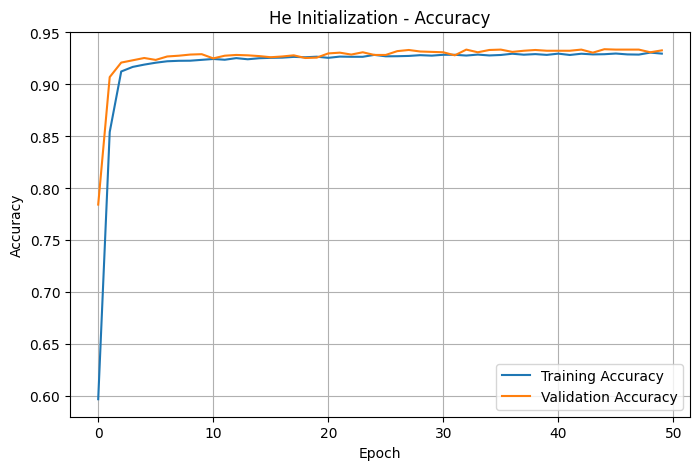

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_he.history['accuracy'], label='Training Accuracy')
plt.plot(history_he.history['val_accuracy'], label='Validation Accuracy')

plt.title('He Initialization - Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

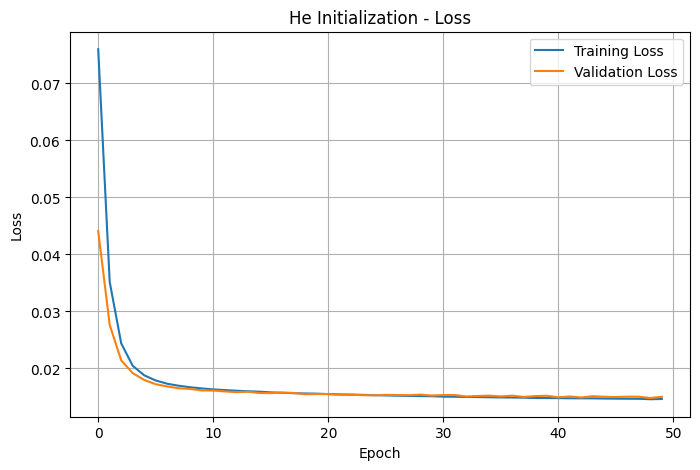

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history_he.history['loss'], label='Training Loss')
plt.plot(history_he.history['val_loss'], label='Validation Loss')

plt.title('He Initialization - Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
print("Train Accuracy :", history_he.history['accuracy'][-1])
print("Validation Accuracy :", history_he.history['val_accuracy'][-1])

print("Train Loss :", history_he.history['loss'][-1])
print("Validation Loss :", history_he.history['val_loss'][-1])

Train Accuracy : 0.9296473264694214
Validation Accuracy : 0.9327946901321411
Train Loss : 0.014629767276346684
Validation Loss : 0.01501579862087965


In [ ]:
y_pred = model.predict(X_test)

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
import numpy as np

y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       261
           1       1.00      1.00      1.00       117
           2       0.95      0.94      0.95       317
           3       0.92      0.92      0.92       671
           4       0.97      0.96      0.96       408
           5       0.97      0.94      0.96       413
           6       0.87      0.90      0.89       536

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred_classes)

print(cm)

[[246   0  11   0   0   0   4]
 [  0 117   0   0   0   0   0]
 [ 12   0 299   0   4   1   1]
 [  0   0   0 617   1   6  47]
 [  2   0   4   5 390   0   7]
 [  6   0   0   8   0 389  10]
 [  0   0   0  44   6   4 482]]


In [ ]:
y_pred = model.predict(X_test)

86/86 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [ ]:
import numpy as np

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes
))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93       261
           1       1.00      1.00      1.00       117
           2       0.95      0.94      0.95       317
           3       0.92      0.92      0.92       671
           4       0.97      0.96      0.96       408
           5       0.97      0.94      0.96       413
           6       0.87      0.90      0.89       536

    accuracy                           0.93      2723
   macro avg       0.94      0.94      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred_classes
)

print(cm)

[[246   0  11   0   0   0   4]
 [  0 117   0   0   0   0   0]
 [ 12   0 299   0   4   1   1]
 [  0   0   0 617   1   6  47]
 [  2   0   4   5 390   0   7]
 [  6   0   0   8   0 389  10]
 [  0   0   0  44   6   4 482]]


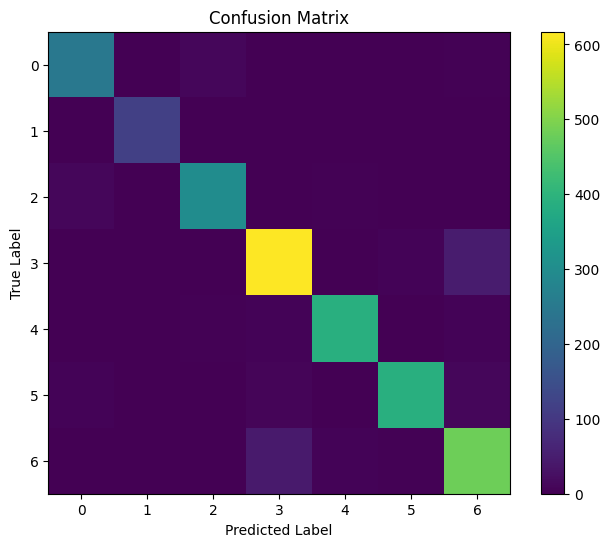

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.imshow(cm)

plt.colorbar()

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.show()

In [ ]:
import pandas as pd

In [ ]:
hasil = pd.DataFrame({

    "Metode": [
        "Zero Initialization",
        "Xavier Initialization",
        "He Initialization"
    ],

    "Train Accuracy": [
        history.history['accuracy'][-1],
        history_xavier.history['accuracy'][-1],
        history_he.history['accuracy'][-1]
    ],

    "Validation Accuracy": [
        history.history['val_accuracy'][-1],
        history_xavier.history['val_accuracy'][-1],
        history_he.history['val_accuracy'][-1]
    ],

    "Train Loss": [
        history.history['loss'][-1],
        history_xavier.history['loss'][-1],
        history_he.history['loss'][-1]
    ],

    "Validation Loss": [
        history.history['val_loss'][-1],
        history_xavier.history['val_loss'][-1],
        history_he.history['val_loss'][-1]
    ]

})

hasil

,Metode,Train Accuracy,Validation Accuracy,Train Loss,Validation Loss
0,Zero Initialization,0.264052,0.246419,0.118034,0.118714
1,Xavier Initialization,0.929004,0.930591,0.014788,0.015225
2,He Initialization,0.929647,0.932795,0.014630,0.015016


In [ ]:
terbaik = hasil.sort_values(
    by="Validation Accuracy",
    ascending=False
)

terbaik

,Metode,Train Accuracy,Validation Accuracy,Train Loss,Validation Loss
2,He Initialization,0.929647,0.932795,0.014630,0.015016
1,Xavier Initialization,0.929004,0.930591,0.014788,0.015225
0,Zero Initialization,0.264052,0.246419,0.118034,0.118714


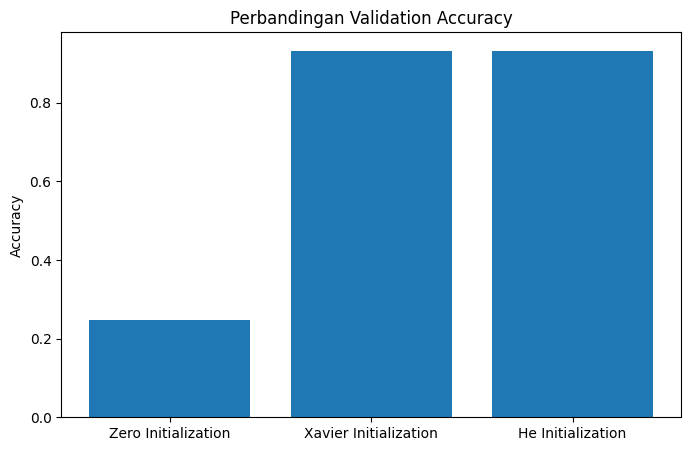

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    hasil["Metode"],
    hasil["Validation Accuracy"]
)

plt.title("Perbandingan Validation Accuracy")

plt.ylabel("Accuracy")

plt.show()

In [ ]:
best = hasil.loc[
    hasil["Validation Accuracy"].idxmax()
]

print(best)

Metode                 He Initialization
Train Accuracy                  0.929647
Validation Accuracy             0.932795
Train Loss                       0.01463
Validation Loss                 0.015016
Name: 2, dtype: object


In [ ]:
hasil.to_excel(
    "Hasil_Perbandingan_ANN.xlsx",
    index=False
)

print("File berhasil disimpan.")

File berhasil disimpan.


In [ ]:
model.save("Model_ANN_He.keras")